# Previsão de tarifa de táxi de Nova Iorque

A base de dados foi extraída desta competição do Kaggle: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/overview. Abaixo a descrição:

> Nesta competição [...] você tem a tarefa de prever o valor da tarifa (inclusive pedágios) para uma corrida de táxi em Nova Iorque, dado os locais de partida e destino. **Embora você possa obter uma estimativa básica baseada apenas na distância entre os dois pontos, isso resultará em um RMSE de 5 a 8**, dependendo do modelo utilizado [...]. Seu desafio é ter resultados melhores do que esses usando técnicas de aprendizagem de máquina!

São disponibilizados duas bases de dados:

>`train.csv` - Características de entrada e valor da taxa, que corresponde a base de dados de treinamento (aproximadamente 55M de linhas).<br>
>`test.csv` - Características de entrada para a base de dados de teste (aproximadamente 10K linhas). O seu objetivo é prever a taxa para cada linha.

### Dicionário do dados:

Variáveis Preditoras
- pickup_datetime - indica quando a corrida de táxi começou.
- pickup_longitude - coordenada de longitude de onde a corrida de táxi começou.
- pickup_latitude - coordenada de latitude de onde a corrida de táxi começou.
- dropoff_longitude - coordenada de longitude de onde a corrida de táxi terminou.
- dropoff_latitude - coordenada de latitude de onde a corrida de táxi terminou.
- passageiro_count - número inteiro que indica o número de passageiros na corrida de táxi.

Variável Target
- fare_amount - valor em dólares do custo da corrida de táxi.

## Importação das bibliotecas

In [1]:
# importa os pacotes necessários
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from datetime import datetime

# suprimi alguns warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [2]:
# versões dos pacotes
%reload_ext watermark
%watermark --iversions

numpy     : 1.26.4
matplotlib: 3.8.3
pandas    : 2.2.1



## Amostragem Aleatória Simples para uma base de dados contendo 55 milhões de registros

O dataset de treino contém 55 milhões de registros como podemos verificar abaixo. Para não sobrecarregar a memoria da minha máquina vou utilizar uma técnica de amostragem para selecionar 5 milhões de registros para o treinamento do modelo.

**A amostragem aleatória simples** confere a cada elemento da população estatística a mesma probabilidade de ser incluído na amostra estudada. Os indivíduos da amostra são, portanto, simplesmente selecionados aleatoriamente, sem utilizar outros critérios.

In [ ]:
# quantidade de entradas no dataset de treino
number_rows_in_file = sum(1 for line in open('new-york-city-taxi-fare-prediction-data/train.csv'))
number_rows_in_file

In [ ]:
# quantidade de entradas para nossa amostra
sample_size = 5000000

In [ ]:
# codigo para selecionar apenas 5000000 de linhas "skipando" o resto
random.seed(24)
skip_rows = sorted(random.sample(range(1, number_rows_in_file + 1),
                                 number_rows_in_file - sample_size))

In [ ]:
# carregando o dataset com apenas o numero de linhas selecionadas
df = pd.read_csv('new-york-city-taxi-fare-prediction-data/train.csv', skiprows = skip_rows)
df.shape

In [ ]:
# salva este novo dataset
df.to_csv('new-york-city-taxi-fare-prediction-data/train_sample_' + str(sample_size) + '.csv', index = False)

## Carregando a base de Treino e Teste

In [3]:
# conjunto de treino
df = pd.read_csv('new-york-city-taxi-fare-prediction-data/train_sample_5000000.csv')

#  conjunto de teste
test = pd.read_csv('new-york-city-taxi-fare-prediction-data/test.csv')

# verificando as dimensões dos conjuntos
print("Dimensões do Conjunto de Treino: ", df.shape)
print("Dimensões do Conjunto de Teste: ", test.shape)

Dimensões do Conjunto de Treino:  (5000000, 8)
Dimensões do Conjunto de Teste:  (9914, 7)


## Análise Exploratória

In [4]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2012-12-03 13:10:00.000000125,9.0,2012-12-03 13:10:00 UTC,-74.006462,40.726713,-73.993078,40.731628,1
1,2011-06-21 16:15:00.00000073,7.3,2011-06-21 16:15:00 UTC,-73.991875,40.754437,-73.977230,40.774323,3
2,2011-08-31 21:14:15.0000003,6.9,2011-08-31 21:14:15 UTC,-73.971114,40.758944,-73.977930,40.736613,1
3,2013-01-29 12:26:00.000000154,9.0,2013-01-29 12:26:00 UTC,-73.992253,40.742657,-73.983597,40.755947,1
4,2009-08-02 02:34:11.0000002,6.9,2009-08-02 02:34:11 UTC,-73.995781,40.723411,-74.005004,40.718950,2


In [5]:
df.dtypes

key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

Como podemos observar o pandas não inferiu corretamente o tipo dos dados, necessitando de uma correção

In [6]:
# manter o dataset original
df_clean = df.copy()

# remove as 4 ultimas posições da variável pickup_datetime e converte para o tipo datetime
df_clean['pickup_datetime'] = pd.to_datetime(df_clean['pickup_datetime'].str.slice(start=0, stop=-4))

# dividi a string pelo '.' e seleciona a primeira posição e converte para o tipo datetime
df_clean['key'] = pd.to_datetime(df_clean['key'].str.split('.').str[0])

In [7]:
# verificando o resultado
df_clean.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2012-12-03 13:10:00,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1
1,2011-06-21 16:15:00,7.3,2011-06-21 16:15:00,-73.991875,40.754437,-73.977230,40.774323,3
2,2011-08-31 21:14:15,6.9,2011-08-31 21:14:15,-73.971114,40.758944,-73.977930,40.736613,1
3,2013-01-29 12:26:00,9.0,2013-01-29 12:26:00,-73.992253,40.742657,-73.983597,40.755947,1
4,2009-08-02 02:34:11,6.9,2009-08-02 02:34:11,-73.995781,40.723411,-74.005004,40.718950,2


In [8]:
df_clean.dtypes

key                  datetime64[ns]
fare_amount                 float64
pickup_datetime      datetime64[ns]
pickup_longitude            float64
pickup_latitude             float64
dropoff_longitude           float64
dropoff_latitude            float64
passenger_count               int64
dtype: object

### Verificando as datas

Conforme a impressão dos 5 primeiros registros da base, observei que os valores da variável `key` e `pickup_datetime` são os mesmos. Será verificado

In [9]:
(df_clean['key'] == df_clean['pickup_datetime']).value_counts()

True    5000000
Name: count, dtype: int64

Conforme visto acima, realmente são valores idênticos, sendo desnecessário manter ambos.

In [10]:
df_clean = df_clean.drop('key', axis=1)

### Verificando se há dados ausentes e/ou duplicados

In [11]:
df_clean.isnull().sum()

fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    32
dropoff_latitude     32
passenger_count       0
dtype: int64

In [12]:
df_clean.duplicated().sum()

8

Foram encontrados 64 registros ausentes nas variáveis `dropoff_longitude` e `dropoff_latitude` e 8 registros duplicados.

Por ser uma quantidade muita pequena com relação a nossa base de dados, ambos serão removidos.

In [13]:
# remove os registros com valores ausentes
df_clean = df_clean.dropna()

# remove os registros com valores duplicados
df_clean = df_clean.drop_duplicates()

df_clean.shape

(4999960, 7)

### Coordenadas

#### `pickup_longitude`

In [14]:
df_clean['pickup_longitude'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean         -72.521133
std           12.923796
min        -3440.696480
25%          -73.992078
50%          -73.981803
75%          -73.967091
max         3454.854513
Name: pickup_longitude, dtype: object

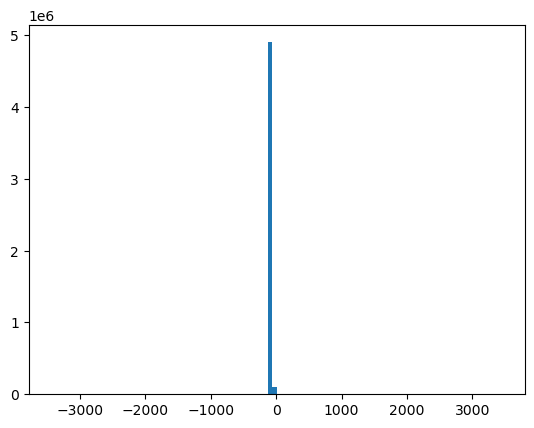

In [15]:
plt.hist(df_clean['pickup_longitude'], bins = 100);

Podemos observar que os valores na faixa entre 25% e 75% parecem serem valores consistentes, porém os valores mínimo e máximo estão com uma característica muito diferente. Podendo ser viagens mais longas. São considerados *outliers*.

Para remover esse valores *outliers* temos algumas técnicas.

- Métodos visuais: como gráficos de dispersão, box plots e histogramas, fornecem uma sensação intuitiva da distribuição de dados e de quaisquer valores extremos.
- Métodos estatísticos: Técnicas como o Z score, IQR (intervalo interquartil) e o Z score modificado. São métodos matemáticos usados para definir valores discrepantes com base na distribuição de dados.
- Modelos probabilísticos e estatísticos: aproveitam a distribuição de probabilidade dos dados, como a distribuição gaussiana, para detectar observações improváveis.

**Para esta solução irei usar o método visual**, pois entregou um resultado melhor. O valor de 0.5 foi definido conforme observação do gráfico.

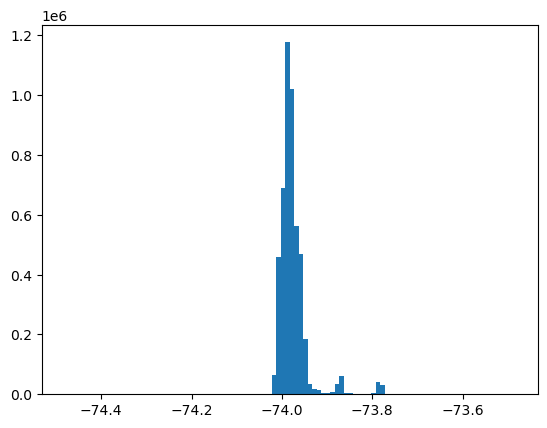

In [16]:
plt.hist(df_clean['pickup_longitude'][(df_clean['pickup_longitude'] > df_clean['pickup_longitude'].median() - 0.5) & 
                                      (df_clean['pickup_longitude'] < df_clean['pickup_longitude'].median() + 0.5)], bins = 100);

In [17]:
plon_val = (df_clean['pickup_longitude'] > df_clean['pickup_longitude'].median() - 0.5) & (df_clean['pickup_longitude'] < df_clean['pickup_longitude'].median() + 0.5)
print(plon_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(round(plon_val.value_counts(normalize=True) * 100), 2)

pickup_longitude
True     4899259
False     100701
Name: count, dtype: int64

Representação em Porcentagem:

pickup_longitude
True     98.0
False     2.0
Name: proportion, dtype: float64 2


Serão removidos 2% dos registros que contém valores *outliers* na variável `pickup_longitude`.

#### `pickup_latitude`

In [18]:
df_clean['pickup_latitude'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean          39.921778
std            8.879919
min        -3441.914335
25%           40.734927
50%           40.752655
75%           40.767145
max         3344.477602
Name: pickup_latitude, dtype: object

Podemos observar o mesmo padrão.

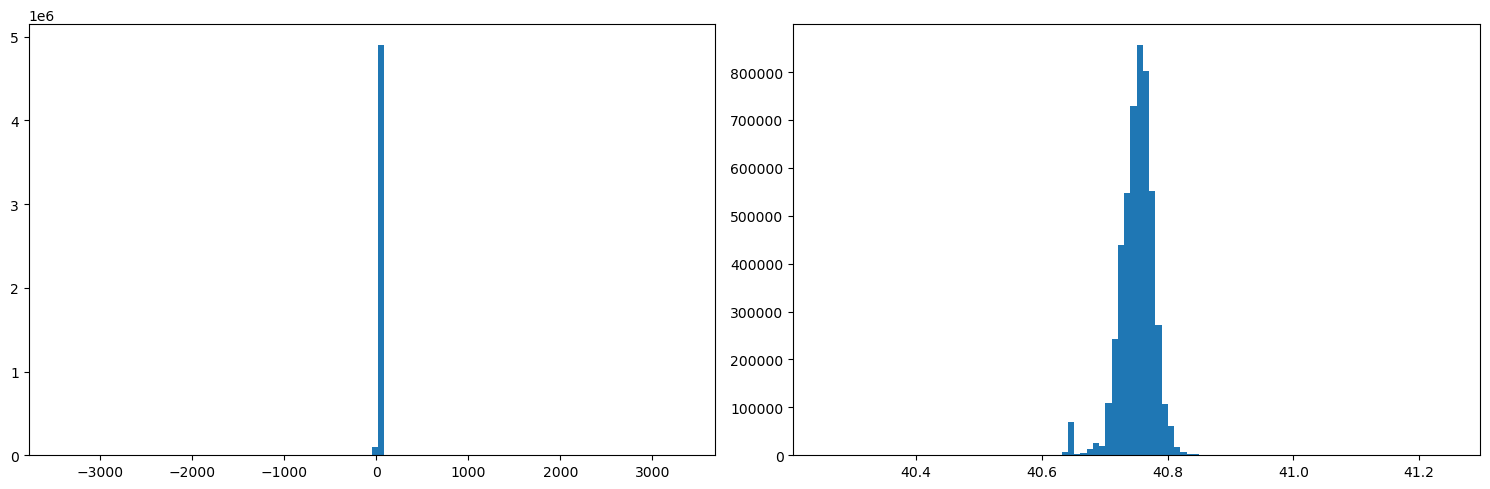

In [19]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].hist(df_clean['pickup_latitude'], bins = 100)
ax[1].hist(df_clean['pickup_latitude'][(df_clean['pickup_latitude'] > df_clean['pickup_latitude'].median() - 0.5) & 
                                       (df_clean['pickup_latitude'] < df_clean['pickup_latitude'].median() + 0.5)], bins = 100)

plt.tight_layout()
plt.show()

In [20]:
plat_val = (df_clean['pickup_latitude'] > df_clean['pickup_latitude'].median() - 0.5) & (df_clean['pickup_latitude'] < df_clean['pickup_latitude'].median() + 0.5)
print(plat_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(round(plat_val.value_counts(normalize=True) * 100), 2)

pickup_latitude
True     4899908
False     100052
Name: count, dtype: int64

Representação em Porcentagem:

pickup_latitude
True     98.0
False     2.0
Name: proportion, dtype: float64 2


#### `dropoff_longitude`

In [21]:
df_clean['dropoff_longitude'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean         -72.518008
std           12.637842
min        -3440.696480
25%          -73.991397
50%          -73.980138
75%          -73.963643
max         3425.444702
Name: dropoff_longitude, dtype: object

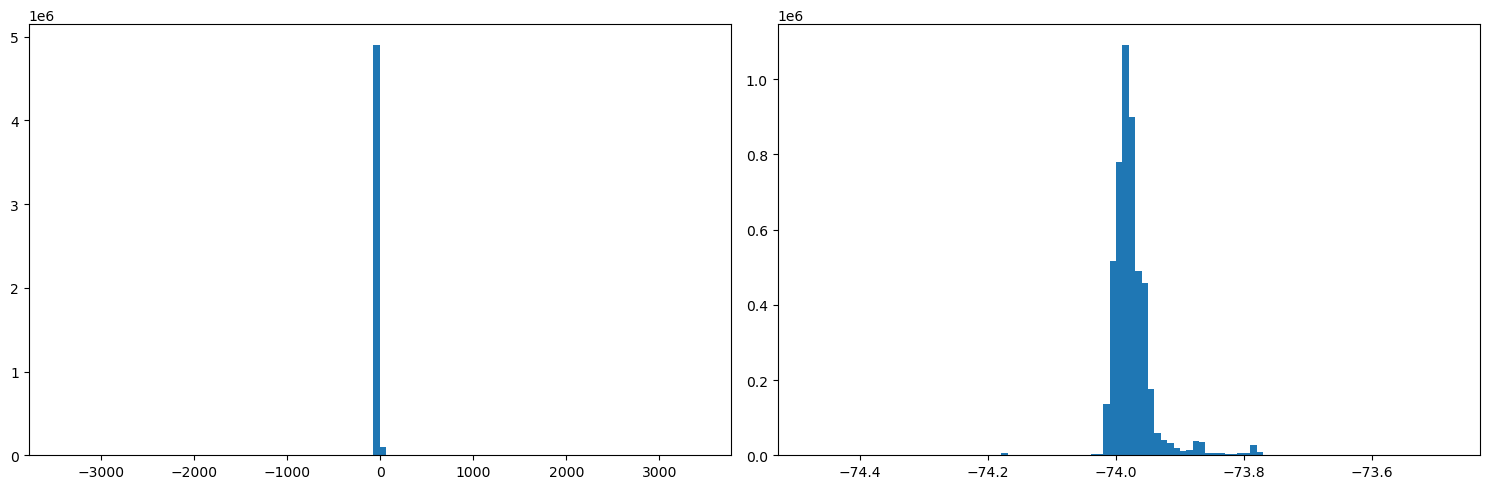

In [22]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].hist(df_clean['dropoff_longitude'], bins = 100)
ax[1].hist(df_clean['dropoff_longitude'][(df_clean['dropoff_longitude'] > df_clean['dropoff_longitude'].median() - 0.5) & 
                                         (df_clean['dropoff_longitude'] < df_clean['dropoff_longitude'].median() + 0.5)], bins = 100)

plt.tight_layout()
plt.show()

In [23]:
dlon_val = (df_clean['dropoff_longitude'] > df_clean['dropoff_longitude'].median() - 0.5) & (df_clean['dropoff_longitude'] < df_clean['dropoff_longitude'].median() + 0.5)
print(dlon_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(round(dlon_val.value_counts(normalize=True) * 100), 2)

dropoff_longitude
True     4899814
False     100146
Name: count, dtype: int64

Representação em Porcentagem:

dropoff_longitude
True     98.0
False     2.0
Name: proportion, dtype: float64 2


#### `dropoff_latitude`

In [24]:
df_clean['dropoff_latitude'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean          39.923875
std            9.656198
min        -3481.141203
25%           40.734052
50%           40.753165
75%           40.768123
max         3333.304575
Name: dropoff_latitude, dtype: object

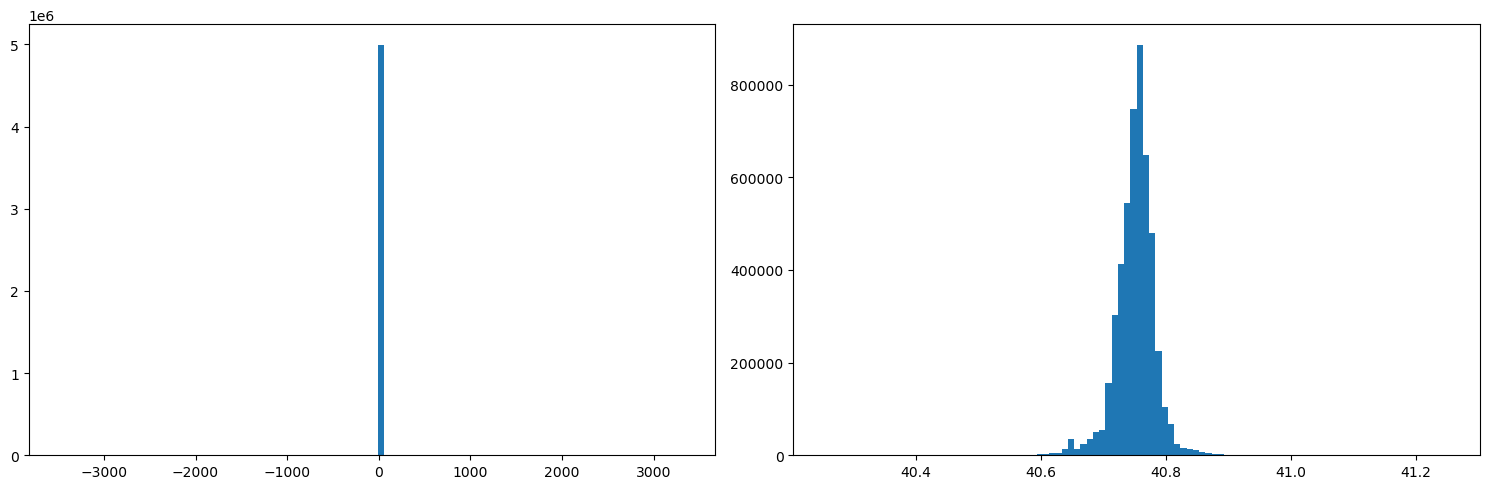

In [25]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].hist(df_clean['dropoff_latitude'], bins = 100)
ax[1].hist(df_clean['dropoff_latitude'][(df_clean['dropoff_latitude'] > df_clean['dropoff_latitude'].median() - 0.5) & 
                                        (df_clean['dropoff_latitude'] < df_clean['dropoff_latitude'].median() + 0.5)], bins = 100)

plt.tight_layout()
plt.show()

In [26]:
dlat_val = (df_clean['dropoff_latitude'] > df_clean['dropoff_latitude'].median() - 0.5) & (df_clean['dropoff_latitude'] < df_clean['dropoff_latitude'].median() + 0.5)
print(dlat_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(round(dlat_val.value_counts(normalize=True) * 100), 2)

dropoff_latitude
True     4900317
False      99643
Name: count, dtype: int64

Representação em Porcentagem:

dropoff_latitude
True     98.0
False     2.0
Name: proportion, dtype: float64 2


### Variável `passenger_count`

In [27]:
df_clean['passenger_count'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean           1.685179
std            1.324649
min            0.000000
25%            1.000000
50%            1.000000
75%            2.000000
max          208.000000
Name: passenger_count, dtype: object

Algumas observações:

- A maioria das corridas de táxi em Nova York tem 1 ou 2 passageiros.
- O *dataset* apresenta registro(s) com 0 passageiros.
- O *dataset* apresenta registro(s) com 208 passageiros.

In [28]:
# quantidade de registros com 0 passageiros e a média que esse valor representa na variável

qtde_0_passageiros = (df_clean['passenger_count'] == 0).sum()

print('Quantidade de registros com 0 passageiros: ', qtde_0_passageiros)
print('Porcentagem na base de dados: ', round(qtde_0_passageiros/df_clean.shape[0], 3))

Quantidade de registros com 0 passageiros:  17403
Porcentagem na base de dados:  0.003


Esses registros com 0 passageiros serão removidos, pois representam apenas 0.003 da nossa base de treinamento

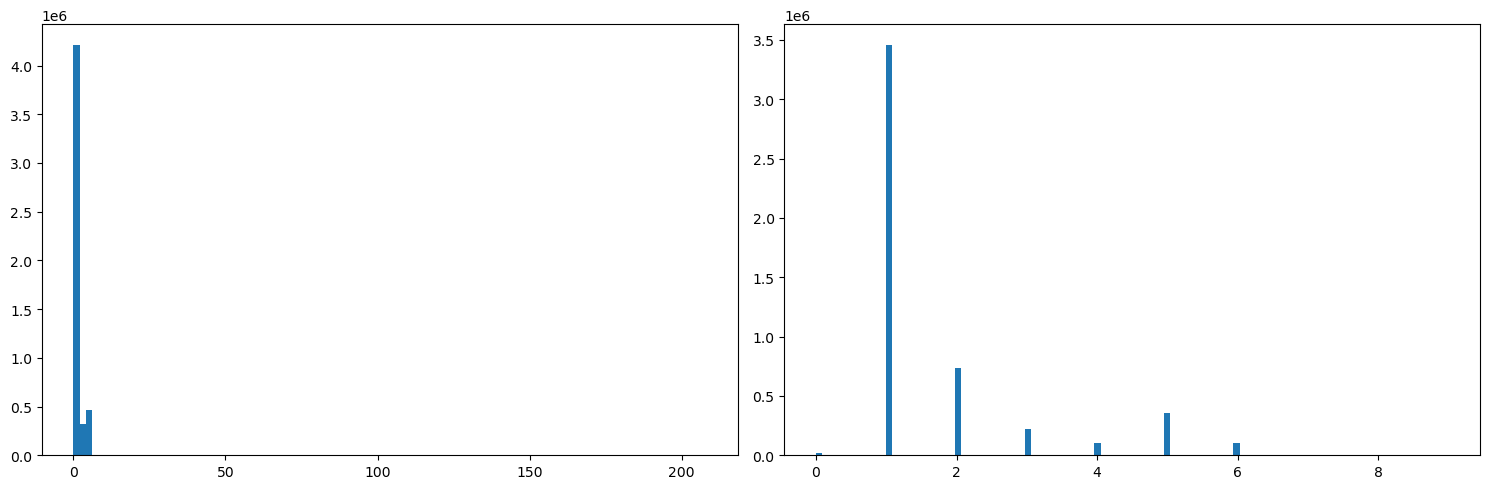

In [29]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].hist(df_clean['passenger_count'], bins = 100)
ax[1].hist(df_clean['passenger_count'][df_clean['passenger_count'] < 20], bins = 100)

plt.tight_layout()
plt.show()

Registros com 0 passageiros e com 7 passageiros pra cima serão removidos da base de treinamento.

In [30]:
pcnt_val = (df_clean['passenger_count'] >= 1) & (df_clean['passenger_count'] <= 6)
print(pcnt_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(pcnt_val.value_counts(normalize=True) * 100)

passenger_count
True     4982548
False      17412
Name: count, dtype: int64

Representação em Porcentagem:

passenger_count
True     99.651757
False     0.348243
Name: proportion, dtype: float64


### Variável `fare_amount`

In [31]:
df_clean['fare_amount'].describe().apply(lambda x: format(x, 'f'))

count    4999960.000000
mean          11.341430
std            9.841584
min         -100.000000
25%            6.000000
50%            8.500000
75%           12.500000
max         1564.500000
Name: fare_amount, dtype: object

O valor minímo da variável apresenta é um valor negativo e não faz sentido termos uma corrida com valor negativo.

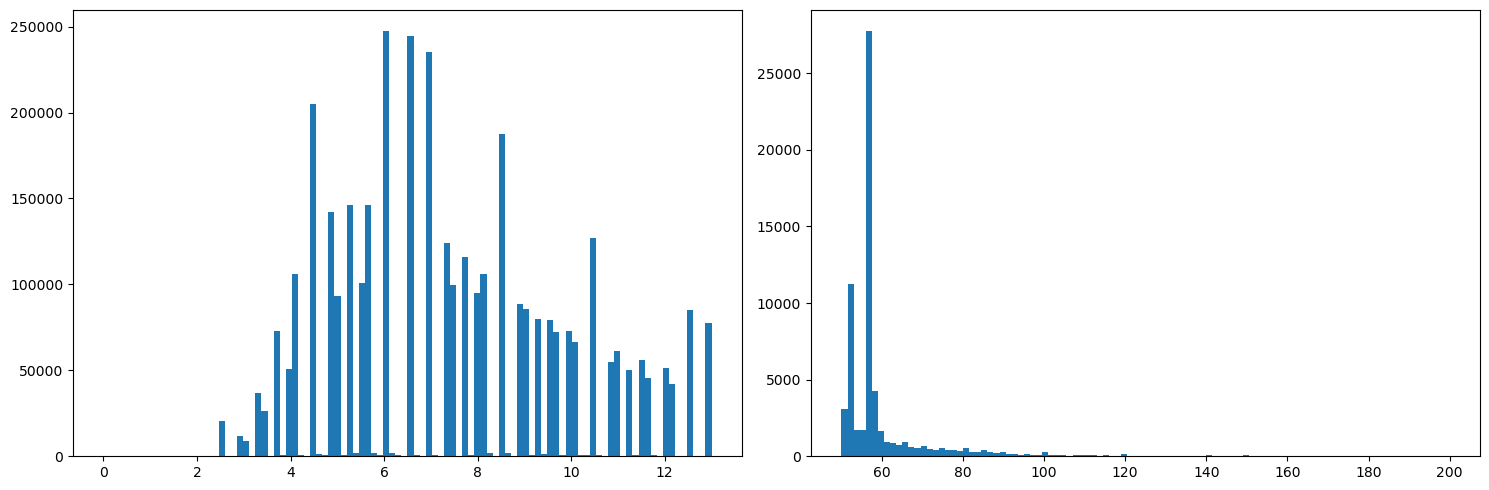

In [32]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].hist(df_clean['fare_amount'], range=(0, 13), bins = 100)
ax[1].hist(df_clean['fare_amount'][df_clean['fare_amount'] > 50], range=(50, 200),bins = 100)

plt.tight_layout()
plt.show()

Podemos observar que os valores minímos das corridas começam acima de 2 dólares e vão até 150 dólares.

In [33]:
fare_val = (df_clean['fare_amount'] > 2) & (df_clean['fare_amount'] < 160)
print(fare_val.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(fare_val.value_counts(normalize=True) * 100)

fare_amount
True     4999120
False        840
Name: count, dtype: int64

Representação em Porcentagem:

fare_amount
True     99.9832
False     0.0168
Name: proportion, dtype: float64


Temos apenas 0,01% de valores fora da nossa condição lógica. O preço da tarifa maior que 2 dólares e menor que 160 dólares

### Remoção dos Valores Outliers

In [34]:
# unindo os valores das variáveis para serem removidos
val_entries = fare_val & plon_val & plat_val & dlon_val & dlat_val & pcnt_val
print(val_entries.value_counts())
print('\nRepresentação em Porcentagem:\n')
print(val_entries.value_counts(normalize=True) * 100)

True     4875165
False     124795
Name: count, dtype: int64

Representação em Porcentagem:

True     97.50408
False     2.49592
Name: proportion, dtype: float64


Serão removidos 2,5% dos registros da base de treinamento.

In [35]:
df_clean = df_clean.drop(val_entries[val_entries == False].index)
df_clean.shape

(4875165, 7)

Nosso *dataset* tinha 4.999.960 registros e após a remoção dos valores *outliers* temos 4.875.165 registros.

## Feature Engineering 

Entendo que os dois fatores mais importantes na tarifa do táxi é a duração da corrida e a distância.

### Duração

A duração da viagem não é dada e não podemos calcular porque a hora de chegada não é dada. Isso faz sentido porque a intenção do modelo é prever a tarifa **antes** da viagem acontecer.

Algo que influencia a duração da viagem é a condição do tráfego. Podemos deduzir usando `pickup_datetime`.

* *hora do dia*: tráfego será menor durante a noite
* *dia da semana*: tráfego será menor nos finais de semana
* *dia do ano*: referiados e férias, por exemplo
* *ano*: pode ser influenciado por mudanças nas regras de transporte ou inflação

In [54]:
df_clean.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day
0,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1,13,0,12,2012,3
1,7.3,2011-06-21 16:15:00,-73.991875,40.754437,-73.977230,40.774323,3,16,1,6,2011,21
2,6.9,2011-08-31 21:14:15,-73.971114,40.758944,-73.977930,40.736613,1,21,2,8,2011,31
3,9.0,2013-01-29 12:26:00,-73.992253,40.742657,-73.983597,40.755947,1,12,1,1,2013,29
4,6.9,2009-08-02 02:34:11,-73.995781,40.723411,-74.005004,40.718950,2,2,6,8,2009,2


In [53]:
# 
df_clean['year'] = df_clean['pickup_datetime'].dt.year
df_clean['month'] = df_clean['pickup_datetime'].dt.month
df_clean['day'] = df_clean['pickup_datetime'].dt.day
df_clean['day_of_week'] = df_clean['pickup_datetime'].dt.dayofweek #The day of the week with Monday=0, Sunday=6.
df_clean['hour'] = df_clean['pickup_datetime'].dt.hour

In [51]:
# análise sobre a distribuição de registros por ano
df_clean.year.value_counts()

year
2012    778062
2011    766637
2013    765694
2009    759306
2010    737448
2014    727158
2015    340860
Name: count, dtype: int64

In [58]:
df_clean[df_clean['year'] == 2015]['month'].value_counts()

month
3    58866
5    58556
4    57537
1    56073
2    55306
6    54522
Name: count, dtype: int64

Podemos observar que o ano de **2015** temos registros até o mês de Junho.

Abaixo podemos verificar que **2012** foi um ano bissesto, portanto, temos o dia 29 de Fevereiro com 2356 registro na base de treinamento.

In [60]:
df_clean[(df_clean['month'] == 2) & (df_clean['day'] == 29)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day
338,8.9,2012-02-29 20:07:35,-73.983967,40.737574,-73.961478,40.768178,1,20,2,2,2012,29
2918,4.5,2012-02-29 23:05:00,-73.977845,40.752235,-73.970375,40.756397,6,23,2,2,2012,29
5914,6.5,2012-02-29 13:22:15,-73.925616,40.744216,-73.915467,40.756606,1,13,2,2,2012,29
7110,20.9,2012-02-29 10:31:00,-74.055413,40.608772,-74.068882,40.518067,2,10,2,2,2012,29
10072,7.7,2012-02-29 21:08:00,-74.006963,40.703842,-74.010033,40.712460,5,21,2,2,2012,29
...,...,...,...,...,...,...,...,...,...,...,...,...
4978072,10.1,2012-02-29 22:29:54,-73.972681,40.759211,-74.005589,40.748258,4,22,2,2,2012,29
4984991,12.1,2012-02-29 19:48:00,-73.985795,40.741740,-74.011587,40.723262,2,19,2,2,2012,29
4988189,10.1,2012-02-29 23:19:00,-73.985095,40.736162,-73.952465,40.768667,1,23,2,2,2012,29
4993365,9.3,2012-02-29 18:53:08,-74.001511,40.726214,-73.981979,40.728124,2,18,2,2,2012,29


In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15,3))
train_not_2015 = train[train['year'] < 2015]
ax[0].hist(train_not_2015['hour_of_day'], bins = 24)
ax[0].set_title('Hour of day')
ax[1].hist(train_not_2015['day_of_week'], bins = 7)
ax[1].set_title('Days of week')
ax[2].hist(train_not_2015['day_of_year'], bins = 365)
ax[2].set_title('Day of year')
ax[3].hist(train_not_2015['year'], bins = 6)
ax[3].set_title('Year')

#### Relações entre pickup_datetime e a demanda

In [ ]:
plt.hist(train['pickup_datetime'], bins = 100)

In [ ]:
plt.figure(figsize = (15, 5))
plt.scatter(train['pickup_datetime'], train['fare_amount'], s = 1, alpha = 0.2)

In [ ]:
from collections import Counter
fare_zoom = train['fare_amount'][(train['fare_amount'] > 40) & (train['fare_amount'] < 60)]

In [ ]:
fare_zoom.shape

In [ ]:
common_fares_zoom = Counter(fare_zoom)

In [ ]:
common_fares_zoom

In [ ]:
most_common_fares_zoom = common_fares_zoom.most_common(10)

In [ ]:
most_common_fares_zoom

In [ ]:
plt.bar([x[0] for x in most_common_fares_zoom], [x[1] for x in most_common_fares_zoom])

Exemplo zorder: https://matplotlib.org/2.0.2/examples/pylab_examples/zorder_demo.html

In [ ]:
from mpl_toolkits.basemap import Basemap

In [ ]:
# Definição da latitude e longitude de NYC
lat1, lat2 = 40.55, 40.95
lon1, lon2 = -74.10, -73.70

plt.figure(figsize = (10, 10))
m = Basemap(projection = 'cyl', resolution = 'h',
            llcrnrlat = lat1, urcrnrlat = lat2,
            llcrnrlon = lon1, urcrnrlon = lon2)
m.drawcoastlines()
m.fillcontinents(color = 'palegoldenrod', lake_color = 'lightskyblue')
m.drawmapboundary(fill_color = 'lightskyblue')
m.drawparallels(np.arange(lat1, lat2 + 0.05, 0.1), labels = [1, 0, 0, 0])
m.drawmeridians(np.arange(lon1, lon2 + 0.05, 0.1), labels = [0, 0, 0, 1])

# Pickup locations - de todas as saídas (verde)
m.scatter(train['pickup_longitude'], train['pickup_latitude'], s = 1, c = 'green',
          alpha = 0.1, zorder = 5)
# Dropoof locations - de todas as saídas (amarelo)
m.scatter(train['dropoff_longitude'], train['dropoff_latitude'], s = 1, c='yellow',
         alpha = 0.1, zorder = 5)
for i in [0, 1, 2, 4]:
  this_fare = most_common_fares_zoom[i][0]
  this_df = train[train['fare_amount'] == this_fare]
  # pickup location - vermelha
  m.scatter(this_df['pickup_longitude'], this_df['pickup_latitude'], s = 2, c = 'red',
           alpha = 0.2, zorder = 5)
  # dropoff location - azul
  m.scatter(this_df['dropoff_longitude'], this_df['dropoff_latitude'], s = 2, c = 'blue',
           alpha = 0.2, zorder = 5)


In [ ]:
coords = train[['dropoff_latitude',
                'dropoff_longitude']][(train['fare_amount'] > 40) &
                                       (train['fare_amount'] < 60) &
                                       (train['dropoff_latitude'] < 40.7) &
                                       (train['dropoff_latitude'] > 40.6) &
                                       (train['dropoff_longitude'] < -73.7) &
                                       (train['dropoff_longitude'] > -73.9)]

In [ ]:
coords.shape

In [ ]:
coords.head()

In [ ]:
print(coords['dropoff_latitude'].median(), coords['dropoff_longitude'].median())

In [ ]:
coords = train[['dropoff_latitude',
                'dropoff_longitude']][(train['fare_amount'] > 40) &
                                       (train['fare_amount'] < 60) &
                                       (train['dropoff_latitude'] < 40.85) &
                                       (train['dropoff_latitude'] > 40.7) &
                                       (train['dropoff_longitude'] < -73.9) &
                                       (train['dropoff_longitude'] > -74.1)]

In [ ]:
print(coords['dropoff_latitude'].median(), coords['dropoff_longitude'].median())

In [ ]:
filtered = train[['fare_amount',
                  'passenger_count']][((train['fare_amount'] == most_common_fares_zoom[0][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[1][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[2][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[4][0]))&
                                       (train['fare_amount'] < 60) &
                                       (train['dropoff_latitude'] < 40.7) &
                                       (train['dropoff_latitude'] > 40.6) &
                                       (train['dropoff_longitude'] < -73.7) &
                                       (train['dropoff_longitude'] > -73.9)]

In [ ]:
filtered.shape

In [ ]:
plt.scatter(filtered['passenger_count'], filtered['fare_amount'])

In [ ]:
filtered = train[['fare_amount',
                  'hour_of_day',
                  'day_of_week',
                  'day_of_year']][((train['fare_amount'] == most_common_fares_zoom[0][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[1][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[2][0]) |
                                       (train['fare_amount'] == most_common_fares_zoom[4][0]))&
                                       (train['fare_amount'] < 60) &
                                       (train['dropoff_latitude'] < 40.7) &
                                       (train['dropoff_latitude'] > 40.6) &
                                       (train['dropoff_longitude'] < -73.7) &
                                       (train['dropoff_longitude'] > -73.9)]

In [ ]:
filtered.shape

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))
ax[0].scatter(filtered['hour_of_day'], filtered['fare_amount'])
ax[0].set_title('Hour of day')
ax[1].scatter(filtered['day_of_week'], filtered['fare_amount'])
ax[1].set_title('Day of week')
ax[2].scatter(filtered['day_of_year'], filtered['fare_amount'])
ax[2].set_title('Day of year')

In [ ]:
train.drop('pickup_datetime', axis = 1, inplace = True)

In [ ]:
train.head()

### Distância

Podemos calcular a distância entre dois pontos geograficos utilizando a [Fórmula de Haversine](https://pt.wikipedia.org/wiki/F%C3%B3rmula_de_Haversine)

A **fórmula de haversine** é uma importante equação usada em navegação, fornecendo *distâncias entre dois pontos* de uma esfera a partir de suas *latitudes e longitudes*. É um caso especial de uma fórmula mais geral de *trigonometria esférica*, a **lei dos haversines**, que relaciona os lados e ângulos de um triângulo contido em uma superfície esférica.

**haversine(θ) = sin²(θ/2)**

Eventualmente, a fórmula se resume ao seguinte, onde φ é a latitude, λ é a longitude, R é o raio da Terra (raio médio = 6.371 km) para incluir as coordenadas de latitude e longitude (A e B neste caso).

**a = sin²((φB - φA)/2) + cos φA . cos φB . sin²((λB - λA)/2)**

**c = 2 * atan2( √a, √(1−a) )**

**d = R ⋅ c**

**d = Haversine distance**

*Atraves desta [pagina](https://community.esri.com/groups/coordinate-reference-systems/blog/2017/10/05/haversine-formula) podemos obter mais informações e exemplos sobre a fórmula Haversine*.

Fórmula de Haversine: https://pt.wikipedia.org/wiki/F%C3%B3rmula_de_Haversine

In [70]:
# Distância Euclidiana (Km)
def haversine_distance(df, p_lon, d_lon, p_lat, d_lat):
    R = 6371 #radius of earth in kilometers
    
    lon1 = np.radians(df[p_lon])
    lon2 = np.radians(df[d_lon])

    lat1 = np.radians(df[p_lat])
    lat2 = np.radians(df[d_lat])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1

   #a = sin²((φB - φA)/2) + cos φA . cos φB . sin²((λB - λA)/2)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

   #c = 2 * atan2( √a, √(1−a) )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

   #d = R * c
    d = (R * c) #in kilometers
    df['harv_distance'] = d
    
    return d

In [71]:
haversine_distance(df_clean, 'pickup_longitude', 'dropoff_longitude', 'pickup_latitude', 'dropoff_latitude')

0          1.253232
1          2.531947
2          2.548615
3          1.647883
4          0.922055
             ...   
4999995    1.048367
4999996    0.790407
4999997    3.330905
4999998    2.289359
4999999    0.426577
Length: 4875165, dtype: float64

In [72]:
df_clean.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day,eucl_distance,harv_distance
0,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1,13,0,12,2012,3,1.253232,1.253232
1,7.3,2011-06-21 16:15:00,-73.991875,40.754437,-73.977230,40.774323,3,16,1,6,2011,21,2.531947,2.531947
2,6.9,2011-08-31 21:14:15,-73.971114,40.758944,-73.977930,40.736613,1,21,2,8,2011,31,2.548615,2.548615
3,9.0,2013-01-29 12:26:00,-73.992253,40.742657,-73.983597,40.755947,1,12,1,1,2013,29,1.647883,1.647883
4,6.9,2009-08-02 02:34:11,-73.995781,40.723411,-74.005004,40.718950,2,2,6,8,2009,2,0.922055,0.922055


In [86]:
df_clean['harv_distance'].describe().apply(lambda x: format(x, 'f'))

count    4875165.000000
mean           3.315314
std            3.586917
min            0.000000
25%            1.253346
50%            2.154326
75%            3.912182
max           69.406248
Name: harv_distance, dtype: object

In [91]:
df_clean[df_clean['harv_distance'] == 0.0]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day,eucl_distance,harv_distance
170,7.3,2011-07-12 16:25:25,-73.990405,40.771739,-73.990405,40.771739,1,16,1,7,2011,12,0.0,0.0
428,6.5,2011-02-15 13:15:28,-73.997734,40.741513,-73.997734,40.741513,1,13,1,2,2011,15,0.0,0.0
475,2.5,2010-07-17 06:24:04,-73.934094,40.751906,-73.934094,40.751906,1,6,5,7,2010,17,0.0,0.0
630,2.9,2011-03-17 11:07:00,-74.001597,40.739490,-74.001597,40.739490,1,11,3,3,2011,17,0.0,0.0
746,6.5,2011-10-09 17:19:00,-73.991492,40.749950,-73.991492,40.749950,2,17,6,10,2011,9,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999618,2.5,2012-12-27 15:14:01,-73.970918,40.758561,-73.970918,40.758561,1,15,3,12,2012,27,0.0,0.0
4999669,49.8,2011-04-24 13:53:00,-73.981197,40.738038,-73.981197,40.738038,1,13,6,4,2011,24,0.0,0.0
4999918,6.0,2014-09-24 10:46:00,-73.965620,40.778082,-73.965620,40.778082,3,10,2,9,2014,24,0.0,0.0
4999923,6.1,2012-08-14 18:58:00,-73.968342,40.755202,-73.968342,40.755202,1,18,1,8,2012,14,0.0,0.0


Muitas viagens de táxi com distância 0 entre os locais de embarque e desembarque, tem cobrança, passageiros, etc.. temos um problema

Text(0, 0.5, 'Long Trip Fare ($)')

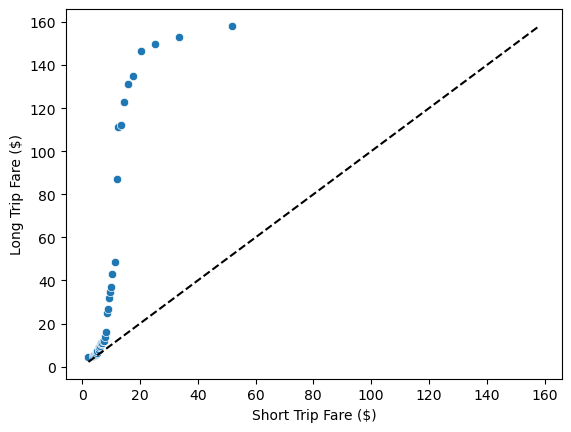

In [93]:
import seaborn as sns

percs = np.linspace(0,99,34)
short = np.percentile(df_clean[df_clean['harv_distance']<=50].fare_amount, percs)
long = np.percentile(df_clean[df_clean['harv_distance']>50].fare_amount, percs)
sns.scatterplot(x=short, y=long)
x = np.linspace(np.min((short.min(),long.min())), np.max((short.max(),long.max())))
plt.plot(x,x, color="k", ls="--")
plt.title('')
plt.xlabel('Short Trip Fare ($)')
plt.ylabel('Long Trip Fare ($)')

In [94]:
import scipy

ks = scipy.stats.ks_2samp(
    df_clean.where(df_clean.harv_distance > 50).dropna()['fare_amount'],
    df_clean.where(df_clean.harv_distance <= 50).dropna()['fare_amount']
)
print('p-value:', ks[1])

p-value: 2.7020081267794014e-07


O pequeno valor p obtido pelo teste de Kolmogorov-Smirnov e o formato do gráfico QQ significam que podemos ter certeza de que esses subconjuntos seguem distribuições diferentes. É difícil dizer qual é a causa dos grandes valores das tarifas, mas há algumas informações codificadas aqui, portanto, não retiraremos essas viagens do conjunto de dados nem imputaremos o valor da tarifa.

À medida que a distância ultrapassa os 75 km, a tarifa média diminui devido a uma massa de pontos em torno de 80-110 km com tarifas abaixo de US$ 50. Essas viagens são em rotas com menos trânsito? Viagens com preço fixo? Ou são dados errados?

In [96]:
long_trips = df_clean[df_clean.harv_distance>25].fare_amount.count()
print(long_trips, 'trips over 75km.')

2792 trips over 75km.


In [97]:
df_clean.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day,eucl_distance,harv_distance
0,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1,13,0,12,2012,3,1.253232,1.253232
1,7.3,2011-06-21 16:15:00,-73.991875,40.754437,-73.977230,40.774323,3,16,1,6,2011,21,2.531947,2.531947
2,6.9,2011-08-31 21:14:15,-73.971114,40.758944,-73.977930,40.736613,1,21,2,8,2011,31,2.548615,2.548615
3,9.0,2013-01-29 12:26:00,-73.992253,40.742657,-73.983597,40.755947,1,12,1,1,2013,29,1.647883,1.647883
4,6.9,2009-08-02 02:34:11,-73.995781,40.723411,-74.005004,40.718950,2,2,6,8,2009,2,0.922055,0.922055


In [98]:
from pyproj import Geod

def distance(lon1,lat1,lon2,lat2):
    az12, az21, dist = Geod(ellps='WGS84').inv(lon1,lat1,lon2,lat2)
    return dist

In [105]:
pickup_long = df.pickup_longitude.tolist()
pickup_lat = df.pickup_latitude.tolist()
dropoff_long = df.dropoff_longitude.tolist()
dropoff_lat = df.dropoff_latitude.tolist()

distance = distance(pickup_long, pickup_lat, dropoff_long, dropoff_lat)

TypeError: 'list' object is not callable

In [107]:
df_clean['distance'] = pd.Series(distance)

In [108]:
df_clean

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year,day,eucl_distance,harv_distance,distance
0,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1,13,0,12,2012,3,1.253232,1.253232,1255.507373
1,7.3,2011-06-21 16:15:00,-73.991875,40.754437,-73.977230,40.774323,3,16,1,6,2011,21,2.531947,2.531947,2530.955260
2,6.9,2011-08-31 21:14:15,-73.971114,40.758944,-73.977930,40.736613,1,21,2,8,2011,31,2.548615,2.548615,2545.771962
3,9.0,2013-01-29 12:26:00,-73.992253,40.742657,-73.983597,40.755947,1,12,1,1,2013,29,1.647883,1.647883,1646.969858
4,6.9,2009-08-02 02:34:11,-73.995781,40.723411,-74.005004,40.718950,2,2,6,8,2009,2,0.922055,0.922055,923.375902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,8.0,2014-08-07 16:05:22,-73.997523,40.746451,-73.991955,40.754883,1,16,3,8,2014,7,1.048367,1.048367,1047.804035
4999996,6.0,2014-10-18 07:51:00,-73.997682,40.724382,-73.994150,40.717797,1,7,5,10,2014,18,0.790407,0.790407,789.800250
4999997,8.1,2012-03-15 07:33:35,-74.004183,40.738263,-73.979732,40.761805,1,7,3,3,2012,15,3.330905,3.330905,3331.462080
4999998,16.5,2014-09-22 09:00:00,-73.977880,40.763550,-73.974020,40.743170,6,9,0,9,2014,22,2.289359,2.289359,2286.535973


Text(0, 0.5, 'Fare ($)')

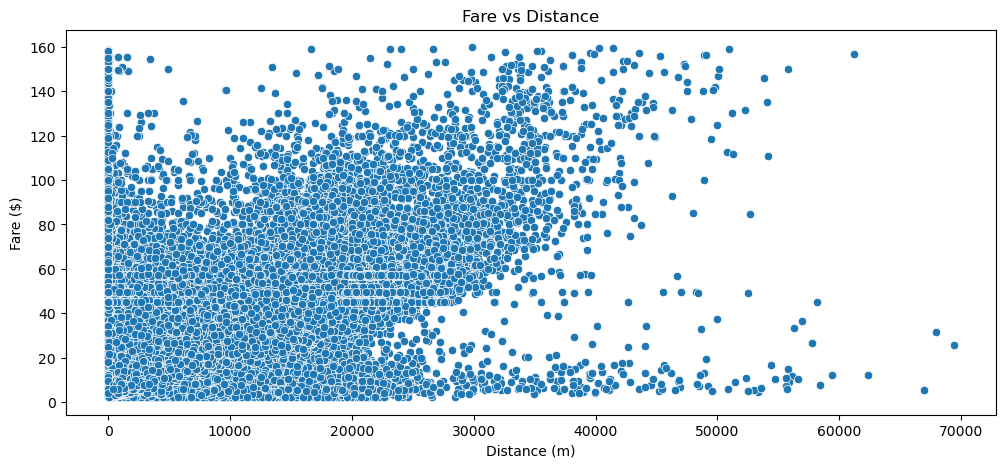

In [109]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(x='distance', y='fare_amount', data=df_clean).set_title('Fare vs Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Fare ($)')

In [112]:
print('Average fare for distance over 75km:', df_clean[df_clean.distance>75000].fare_amount.mean())
print('Average fare for distance 50-75km:', df_clean.query('50000 < distance < 75000').fare_amount.mean())
sns.barplot(['50-75km', '>75km'],[df_clean.query('50000 < distance < 75000').fare_amount.mean(),df_clean[df_clean.distance>75000].fare_amount.mean()])
plt.title('Fare by Trip Distance')
plt.ylabel('Fare ($)')
plt.xlabel('Distance')

Average fare for distance over 75km: nan
Average fare for distance 50-75km: 53.864999999999995


TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

Text(0, 0.5, 'Fare ($)')

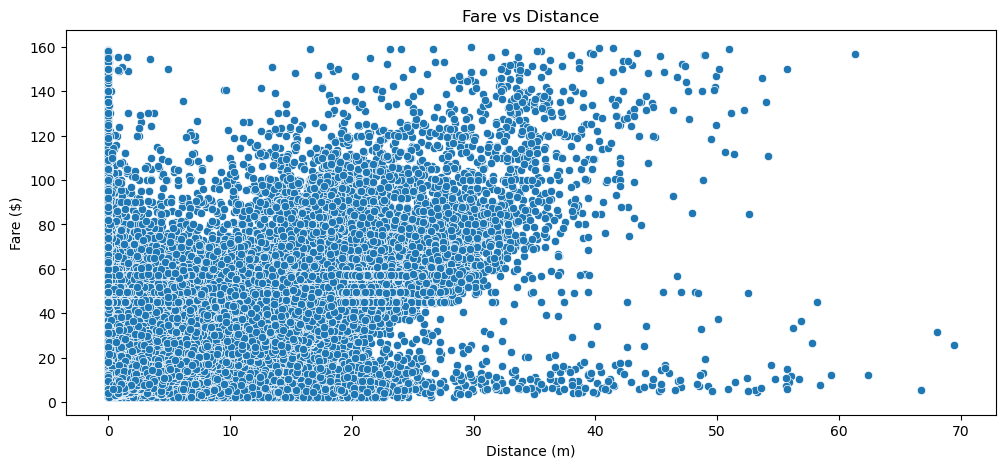

In [84]:
fig = plt.figure(figsize=(12, 5))

sns.scatterplot(x='harv_distance', y='fare_amount', data=df_clean).set_title('Fare vs Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Fare ($)')

## Pré-processamento

In [ ]:
X_train = train.drop('fare_amount', axis = 1)

In [ ]:
y_train = train['fare_amount']

In [ ]:
X_train.head()

In [ ]:
y_train

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [ ]:
X_train_scaled[0]

## Treinamento

In [ ]:
from sklearn.model_selection import cross_val_score
cv = 3
scoring = 'neg_mean_squared_error'
import multiprocessing
n_jobs = multiprocessing.cpu_count() - 1

In [ ]:
n_jobs

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
model = Ridge()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
model = Lasso()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

### Deep Learning

In [ ]:
from sklearn.neural_network import MLPRegressor
model = MLPRegressor()
scores = cross_val_score(model, X_train_scaled, y_train, cv = cv,
                         scoring = scoring, n_jobs = n_jobs)
np.sqrt(-scores.mean())

## Inspecionando o melhor modelo

### Dividindo a base de dados

In [ ]:
from sklearn.model_selection import train_test_split
X_train1, X_test, y_train1, y_test = train_test_split(X_train_scaled, y_train,
                                                      test_size = 0.2, random_state = 24)

In [ ]:
X_train1.shape

In [ ]:
X_test.shape

### Treinamento do modelo

In [ ]:
model = GradientBoostingRegressor()
model.fit(X_train1, y_train1)

### Inspecionando o modelo

In [ ]:
features_importances = model.feature_importances_

In [ ]:
features_importances

In [ ]:
argsort = np.argsort(features_importances)

In [ ]:
argsort

In [ ]:
features_importances_sorted = features_importances[argsort]

In [ ]:
features_importances_sorted

In [ ]:
feature_names = X_train.columns

In [ ]:
feature_names

In [ ]:
features_sorted = feature_names[argsort]

In [ ]:
features_sorted

In [ ]:
plt.barh(features_sorted, features_importances_sorted)

In [ ]:
mse = model.train_score_[-1]

In [ ]:
mse

In [ ]:
rmse = np.sqrt(mse)
rmse

## Previsões na base de dados de teste

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

### Comparando as previsões com as respostas reais

In [ ]:
print_every = int(sample_size / 1000)
print_every

In [ ]:
fig = plt.figure(figsize=(20,5))
plt.bar(list(range(len(y_test[::print_every]))), y_test.values[::print_every],
        alpha = 1, color = 'red', width = 1, label = 'true values')
plt.bar(list(range(len(y_pred[::print_every]))), y_pred[::print_every],
        alpha = 0.5, color = 'blue', width = 1, label = 'predicted values')
plt.legend()

## Respondendo o desafio

Instruções

> **Submission File** <br>
> For each `key` in the test set, you must predict a value for the `fare_amount` variable. The file should contain a header and have the following format:
>
> ```
> key,fare_amount
> 2015-01-27 13:08:24.0000002,11.00 ```



In [ ]:
test = pd.read_csv('test.csv',
                    parse_dates = ['pickup_datetime'],
                    dtype = {'fare_amount': np.float32,
                             'pickup_latitude': np.float32,
                             'pickup_longitude': np.float32,
                             'dropoff_latitude': np.float32,
                             'dropoff_longitude': np.float32,
                             'passenger_count': np.int32,
                             'key': str
                    })

In [ ]:
test.shape

In [ ]:
key = test['key']

In [ ]:
# Data
pdt = test['pickup_datetime']
pdt = pdt.map(lambda date: date.tz_localize(None))
test.drop(['key'], axis = 1, inplace=True)
test['pickup_datetime'] = pdt

In [ ]:
# Novos atributos
test['day_of_week'] = test['pickup_datetime'].map(lambda date: date.timetuple().tm_wday)
test['day_of_year'] = test['pickup_datetime'].map(lambda date: date.timetuple().tm_yday)
test['year'] = test['pickup_datetime'].map(lambda date: date.timetuple().tm_year)
test['hour_of_day'] = test['pickup_datetime'].map(lambda date: date.timetuple().tm_hour)
test.drop('pickup_datetime', axis = 1, inplace = True)

# Distância
lon1, lon2 = np.radians(test['pickup_longitude']), np.radians(test['dropoff_longitude'])
lat1, lat2 = np.radians(test['pickup_latitude']), np.radians(test['dropoff_latitude'])
dlon = lon2 - lon1
dlat = lat2 - lat1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
test['eucl_distance'] = 6373 * c

a1 = np.sin(dlon/2)**2
c1 = 2 * np.arctan2(np.sqrt(a1), np.sqrt(1-a1))
a2 = np.sin(dlat/2)**2
c2 = 2 * np.arctan2(np.sqrt(a2), np.sqrt(1-a2))
test['manh_distance'] = 6373 * (c1+c2)

In [ ]:
test.head()

In [ ]:
X_test = test
X_test_scaled = scaler.transform(X_test)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred

In [ ]:
submission = pd.DataFrame({'key': key, 'fare_amount': y_pred})

In [ ]:
submission.head()

In [ ]:
submission.to_csv('submission.csv', index = False)

## Melhorias

> Testes com outros modelos, como por exemplo: XGBoost e SVm (SVR)

> Otimização dos parâmetros

> Melhor análise sobre feature engineering